# NEU-DET — Exploratory Data Analysis

**SoS 2026 — Steel Surface Defect Detection (Week 4 midterm)**

EDA on the NEU surface-defect dataset: class balance, sample images with boxes, bounding-box size/aspect distributions, boxes-per-image, and image dimensions.

> Set `DATA_DIR` below to wherever you downloaded the dataset (the path printed by `scripts/download_data.py`), then **Run All**. Commit this notebook *with its outputs* so the charts are visible in the repo.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# >>> EDIT THIS to your dataset root <<<
DATA_DIR = Path('/kaggle/input/neu-surface-defect-database')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
assert DATA_DIR.exists(), f'DATA_DIR not found: {DATA_DIR}'

## Parse all annotations into a DataFrame

In [2]:
images = {p.stem: p for p in DATA_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS}

rows = []
for xml in DATA_DIR.rglob('*.xml'):
    root = ET.parse(xml).getroot()
    size = root.find('size')
    iw = int(float(size.findtext('width'))) if size is not None else None
    ih = int(float(size.findtext('height'))) if size is not None else None
    for obj in root.findall('object'):
        name = (obj.findtext('name') or '').strip()
        bb = obj.find('bndbox')
        if not name or bb is None:
            continue
        xmin, ymin = float(bb.findtext('xmin')), float(bb.findtext('ymin'))
        xmax, ymax = float(bb.findtext('xmax')), float(bb.findtext('ymax'))
        rows.append(dict(stem=xml.stem, cls=name, img_w=iw, img_h=ih,
                         xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax,
                         box_w=xmax - xmin, box_h=ymax - ymin))

df = pd.DataFrame(rows)
df['area'] = df['box_w'] * df['box_h']
df['aspect'] = df['box_w'] / df['box_h']
print(f'{len(df)} boxes across {df.stem.nunique()} images, {df.cls.nunique()} classes')
df.head()

4189 boxes across 1800 images, 6 classes


,stem,cls,img_w,img_h,xmin,ymin,xmax,ymax,box_w,box_h,area,aspect
0,scratches_246,scratches,200,200,2.0,157.0,180.0,171.0,178.0,14.0,2492.0,12.714286
1,patches_258,patches,200,200,91.0,60.0,154.0,148.0,63.0,88.0,5544.0,0.715909
2,patches_258,patches,200,200,132.0,144.0,167.0,185.0,35.0,41.0,1435.0,0.853659
3,patches_258,patches,200,200,22.0,81.0,52.0,116.0,30.0,35.0,1050.0,0.857143
4,crazing_241,crazing,200,200,42.0,124.0,183.0,184.0,141.0,60.0,8460.0,2.350000


## Class distribution

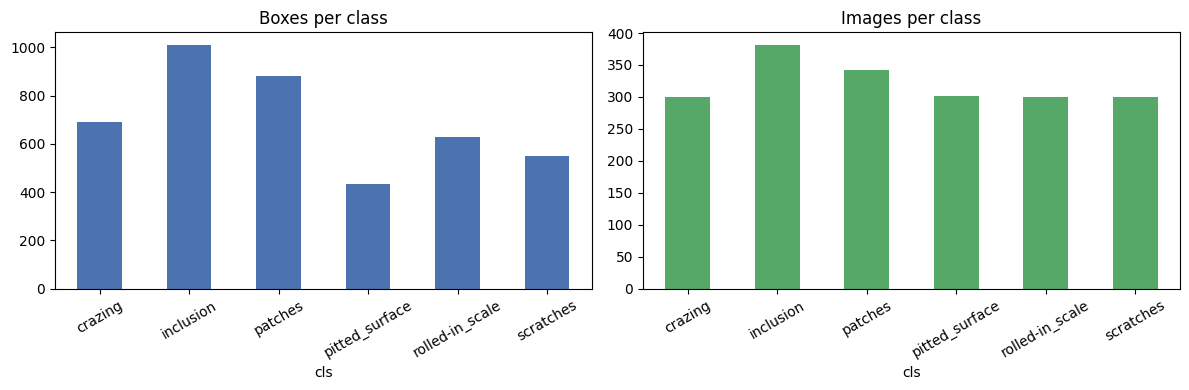

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['cls'].value_counts().sort_index().plot.bar(ax=ax[0], title='Boxes per class', color='#4C72B0')
df.groupby('cls')['stem'].nunique().sort_index().plot.bar(ax=ax[1], title='Images per class', color='#55A868')
for a in ax:
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## Sample image per class (with ground-truth boxes)

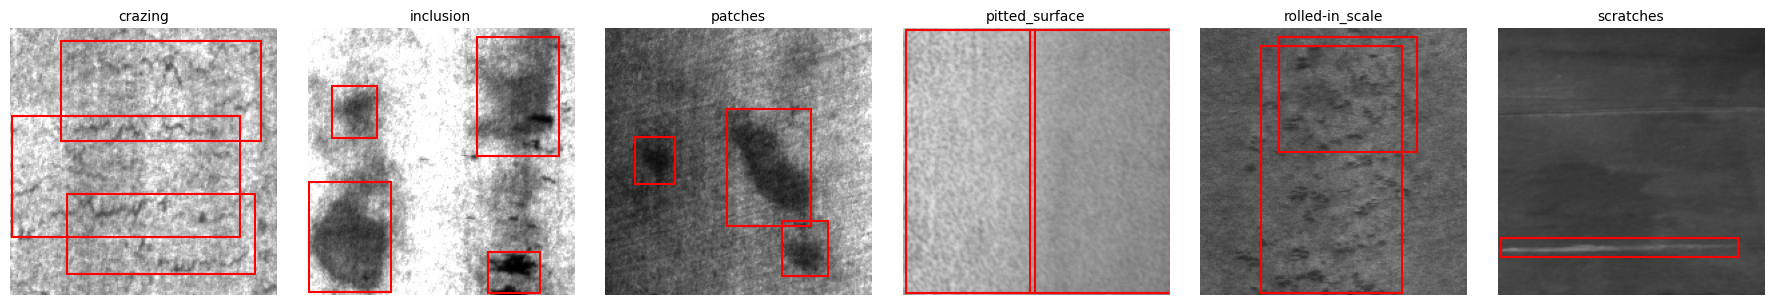

In [4]:
classes = sorted(df['cls'].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
for ax, c in zip(np.atleast_1d(axes), classes):
    stem = df[df['cls'] == c]['stem'].iloc[0]
    ax.imshow(Image.open(images[stem]).convert('RGB'))
    for _, b in df[df['stem'] == stem].iterrows():
        ax.add_patch(plt.Rectangle((b.xmin, b.ymin), b.box_w, b.box_h,
                                   fill=False, edgecolor='red', lw=1.5))
    ax.set_title(c, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

## Bounding-box size and aspect distributions

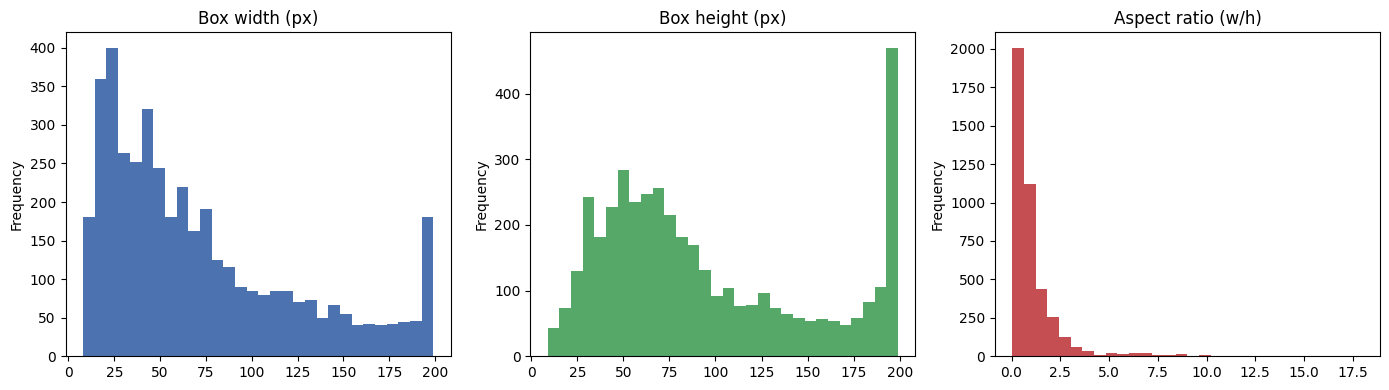

,box_w,box_h,area,aspect
count,4189.00,4189.00,4189.00,4189.00
mean,71.40,95.01,6980.19,1.13
std,52.04,56.54,7546.10,1.52
min,8.00,9.00,108.00,0.05
25%,30.00,50.00,2052.00,0.37
50%,55.00,77.00,4715.00,0.68
75%,100.00,136.00,8763.00,1.26
max,199.00,199.00,39601.00,18.00


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
df['box_w'].plot.hist(bins=30, ax=ax[0], title='Box width (px)', color='#4C72B0')
df['box_h'].plot.hist(bins=30, ax=ax[1], title='Box height (px)', color='#55A868')
df['aspect'].plot.hist(bins=30, ax=ax[2], title='Aspect ratio (w/h)', color='#C44E52')
plt.tight_layout(); plt.show()
df[['box_w', 'box_h', 'area', 'aspect']].describe().round(2)

## Boxes per image

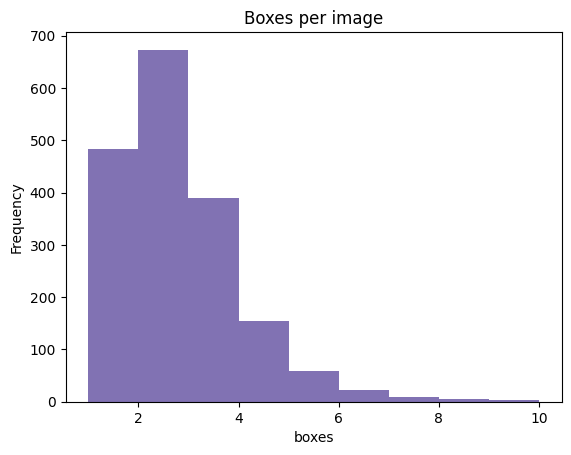

avg boxes/image: 2.33 | max: 9


In [6]:
per_img = df.groupby('stem').size()
per_img.plot.hist(bins=range(1, int(per_img.max()) + 2), title='Boxes per image', color='#8172B3')
plt.xlabel('boxes'); plt.show()
print('avg boxes/image:', round(per_img.mean(), 2), '| max:', int(per_img.max()))

## Image dimensions (sanity check)

In [7]:
print('Unique (width, height) pairs in annotations:')
print(df[['img_w', 'img_h']].drop_duplicates().to_string(index=False))

Unique (width, height) pairs in annotations:
 img_w  img_h
   200    200


## Summary of findings

_Fill these in after running (a few sentences each):_

- **Class balance:** _e.g. roughly balanced, ~300 images per class._
- **Boxes per image:** _typical count and range._
- **Box sizes / aspect:** _are defects large/small, elongated, varied?_
- **Image size:** _all 200x200 confirmed._
- **Implications for training:** _e.g. small balanced dataset -> rely on transfer learning + augmentation._